In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

In [33]:
class MathState(TypedDict):
    value: int
    stage: str

In [34]:
def square(state: MathState) -> MathState:
    x = state['value']
    state['value'] = x * x
    state['stage'] = 'squared'
    return state

def increase_by_one(state: MathState) -> MathState:
    state['value'] += 1
    state['stage'] = 'increased'
    return state

In [35]:
def show_workflow_image(workflow: StateGraph) -> Image:
    return Image(workflow.get_graph().draw_mermaid_png())

In [43]:
# Graph
graph = StateGraph(MathState)

# Nodes
graph.add_node("square node", square)
graph.add_node("increase_by_one node", increase_by_one)

# Edges
graph.add_edge(START, "square node")
graph.add_edge("square node", "increase_by_one node")
graph.add_edge("increase_by_one node", END)

In [44]:
workflow = graph.compile()

In [45]:
initial_state = MathState(value=2, stage="start")
final_state = workflow.invoke(initial_state)
print(final_state)

{'value': 5, 'stage': 'increased'}


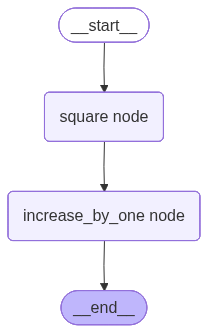

In [46]:
show_workflow_image(workflow)